## Gamma Ray Bursts.

Let's look at the latest database of Gamma Ray Bursts.

 - The database can be downloaded at https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt
 - You can find the physical meaning of each variable at https://user-web.icecube.wisc.edu/~grbweb_public/Variables.html 


This edition of "get your hands dirty" is very open ended (we're getting closer and closer to real research...). You have a cool dataset, explore it! Play with the data, apply some of the tecniques we have seen in classes so far, etc. **Be creative! You're discovering**


Some relevant physical questions you might want to tackle include:

- Does the distribution contain different sub-populations? How many?
- What's the threshold between the classes?
- If you try two clustering methods, do you get more or less the same?
- How do methods respond to outliers?
- What variable(s) shows the multi-modality more evidently?
- Are all GRBs equally likely to be observed? 



In [252]:
import requests
import numpy as np

import matplotlib.pyplot as plt
import astropy.visualization.hist

from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity
from scipy.signal import find_peaks

from sklearn.mixture import GaussianMixture

from sklearn.cluster import KMeans
from sklearn import preprocessing
import seaborn as sns

#### Python tip. Web request and smarter file reading

In [253]:
# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read headers
with open("Summary_table.txt",'r') as f:
    names= np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str', unpack=True, skiprows=3)


C:\Users\emmag\AppData\Local\Temp\ipykernel_23660\2539225335.py:11: UserWarning: Input line 4 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt("Summary_table.txt", dtype='str', unpack=True, skiprows=3)


[My exploration](https://github.com/dgerosa/astrostatistics_bicocca_2025/blob/main/solutions/S15_gammaraybursts.ipynb) which, by the way, does not answer all the questions above...

In [254]:
data

array([['GRB250615A', 'GRB250612C', 'GRB250612B', ..., 'GRB910424A*',
        'GRB910423A*', 'GRB910421A*'],
       ['None', 'GRB250612620', 'GRB250612519', ..., 'None', 'None',
        'None'],
       ['22:25:19.590', '14:53:11.512', '12:27:55.934', ...,
        '19:43:25.064', '19:51:15.804', '9:14:03.800'],
       ...,
       ['-999', '6.7660', '10.7520', ..., '3.1360', '208.5760', '5.6960'],
       ['False', 'True', 'False', ..., 'False', 'False', 'False'],
       ['60841.93425451', '60838.62027213', '60838.51939738', ...,
        '48370.82181787', '48369.82726625', '48367.38476620']],
      dtype='<U14')

In [255]:
# Right ascension in J2000 coordinates. If the GRB was observed by multiple instruments, the localisation with the smallest angular uncertainty is used.
ra_s = np.array(data[3],dtype=float)

# Declination in J2000 coordinates. If the GRB was observed by multiple instruments, the localisation with the smallest angular uncertainty is used.
decl_s = np.array(data[4],dtype=float)

# 1σ error on the localisation. A 2d Gaussian pdf is assumed, implying that the probability that the true position of the GRB lies within 1σ degrees is ~39.3%.
posErr_s = np.array(data[5],dtype=float)

# Duration of the time interval during which 90% of the GRB photon counts are observed, starting at 5% and ending at 95%. This parameter depends on the efficiency with which photons of various energies can be observed, making the T90 dependent on the detector.
T90_s = np.array(data[6],dtype=float)

# Estimated 1σ error on the duration of the T90 interval.
T90Err_s = np.array(data[7],dtype=float)

# The time integrated total energy per unit surface. Please note that the observed value strongly depends on the energy band and thus the detector that observed the burst.
# - For the Fermi-GBM detector, the energy band is 10-1000 keV.
# - For the Swift (BAT) detector, the energy band is 15-150 keV.
# - For the BeppoSAX detector, the energy band is 40-700 keV.
# -For the BATSE detector, the energy band is 20-300 keV.
fluence_s = np.array(data[9],dtype=float)

# Estimated 1σ error on the fluence.
fluenceErr_s = np.array(data[10],dtype=float)

# Distance to the GRB.
z_s = np.array(data[11],dtype=float)


# mask unphysical values
T90 = T90_s[T90_s>0]
z = z_s[z_s>0]
fluence = fluence_s[fluence_s>0]

# Sky Map

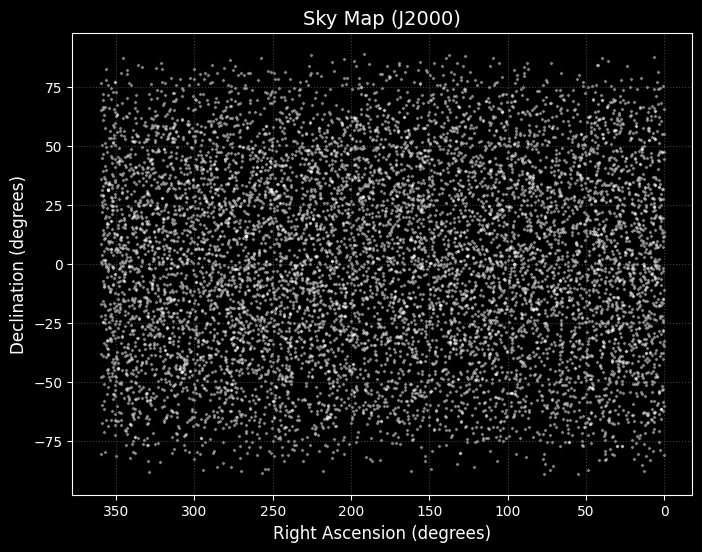

In [283]:
plt.figure(figsize=(8,6))
plt.style.use('dark_background')  
plt.scatter(ra_s, decl_s, s=1, color='white', marker='P', alpha=0.5)
plt.xlabel('Right Ascension (degrees)', color='white', fontsize=12)
plt.ylabel('Declination (degrees)', color='white', fontsize=12)
plt.title('Sky Map (J2000)', color='white', fontsize=14)
plt.tick_params(axis='both', colors='white')
plt.grid(linestyle=":", color='gray', alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

# 1-D distributions

I here report the 1-dimensional distribution of the three variables I decided to study. I will then apply some statistics to see if I can catch some of the features of these curves, and link them to the physics of gamma ray bursts (which I know little about, but will compensate with the help of Google). 

### Redshift

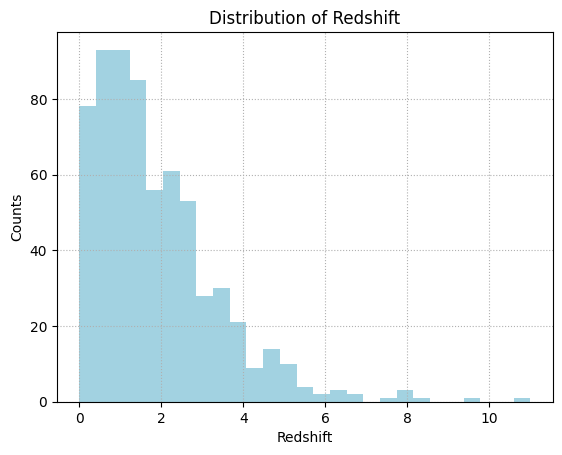

In [257]:
plt.style.use('default')

plt.hist(z, bins='fd', color='c', alpha =0.6)
plt.title('Distribution of Redshift')
plt.xlabel('Redshift')
plt.ylabel('Counts')
plt.grid(linestyle=':')
plt.show()

In [258]:
bwrange = np.linspace(0.01, 1, 40) # Test 10 bandwidths from 0.1 to 1.0
#print(bwrange)
K = 5 # Do 5-fold cross validation

grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K) # Try each bandwidth with K-folds
grid.fit(z[:, None]) #Fit the histogram data 
h_opt = grid.best_params_['bandwidth'] 

print(h_opt)

0.4923076923076923


In [259]:
def kde_sklearn(data, bandwidth, xgrid):
    kde_skl = KernelDensity(bandwidth=bandwidth)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis])  # usa xgrid passato come argomento
    return np.exp(log_pdf)

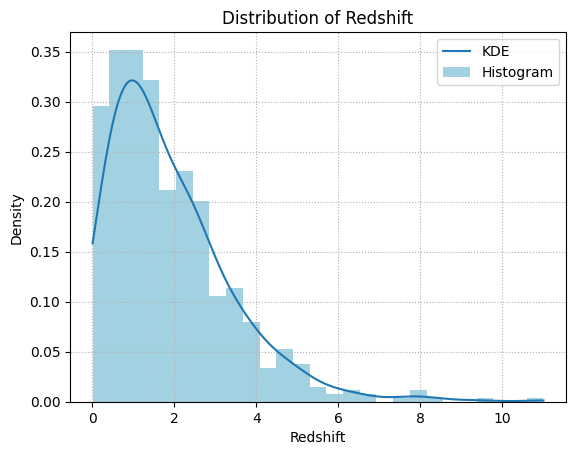

In [260]:
xgrid =np.linspace(z.min(),z.max(),1000)
pdf = kde_sklearn(z,bandwidth=h_opt, xgrid=xgrid)
plt.plot(xgrid,pdf, label = 'KDE')
plt.hist(z, bins='fd', color='c', density= True,alpha =0.6, label='Histogram')
plt.title('Distribution of Redshift')
plt.xlabel('Redshift')
plt.ylabel('Density')
plt.grid(linestyle=':')
plt.legend()
plt.show()

In [261]:
peaks_z, _ = find_peaks(pdf)

print(f"Number of peaks found for redshift: {len(peaks_z)}")
print(f"Peaks at values of redshift (log10): {xgrid[peaks_z]}")

Number of peaks found for redshift: 3
Peaks at values of redshift (log10): [ 0.97672022  7.84228178 10.9889975 ]


### Fluence and Time

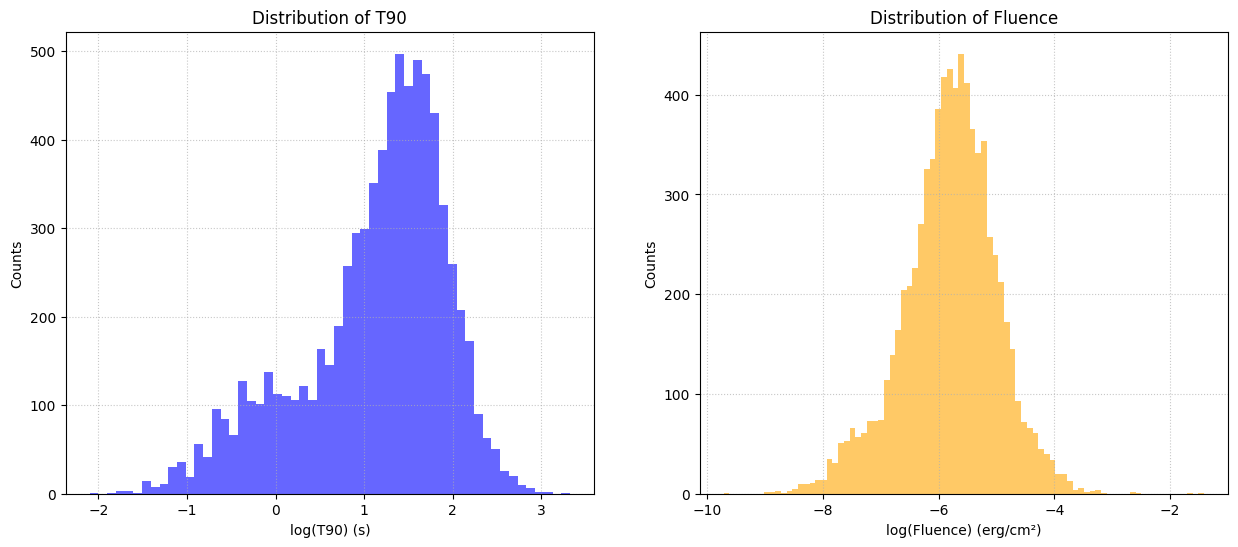

In [262]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# First histogram: T90
ax1.hist(np.log10(T90), bins="fd", color='blue', alpha=0.6)
ax1.set_title('Distribution of T90')
ax1.set_xlabel('log(T90) (s)')
ax1.set_ylabel('Counts')
ax1.grid(True, linestyle=':', alpha=0.7)

# Second histogram: fluence
ax2.hist(np.log10(fluence), bins="fd", color='orange', alpha=0.6)
ax2.set_title('Distribution of Fluence')
ax2.set_xlabel('log(Fluence) (erg/cm²)')
ax2.set_ylabel('Counts')
ax2.grid(True, linestyle=':', alpha=0.7)

plt.show()


In [263]:
bwrange = np.linspace(0.01, 0.5, 20) # Test 10 bandwidths from 0.1 to 1.0
#print(bwrange)

K = 5 # Do 5-fold cross validation

X_f = np.log10(fluence[:, None])
X_t = np.log10(T90[:, None])

h_opt_arr = []

for X in [X_f, X_t]:

    grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K) # Try each bandwidth with K-folds
    grid.fit(X) #Fit the histogram data 

    h_opt_arr.append(grid.best_params_['bandwidth'])
    
print(np.array(h_opt_arr))


[0.29368421 0.11315789]


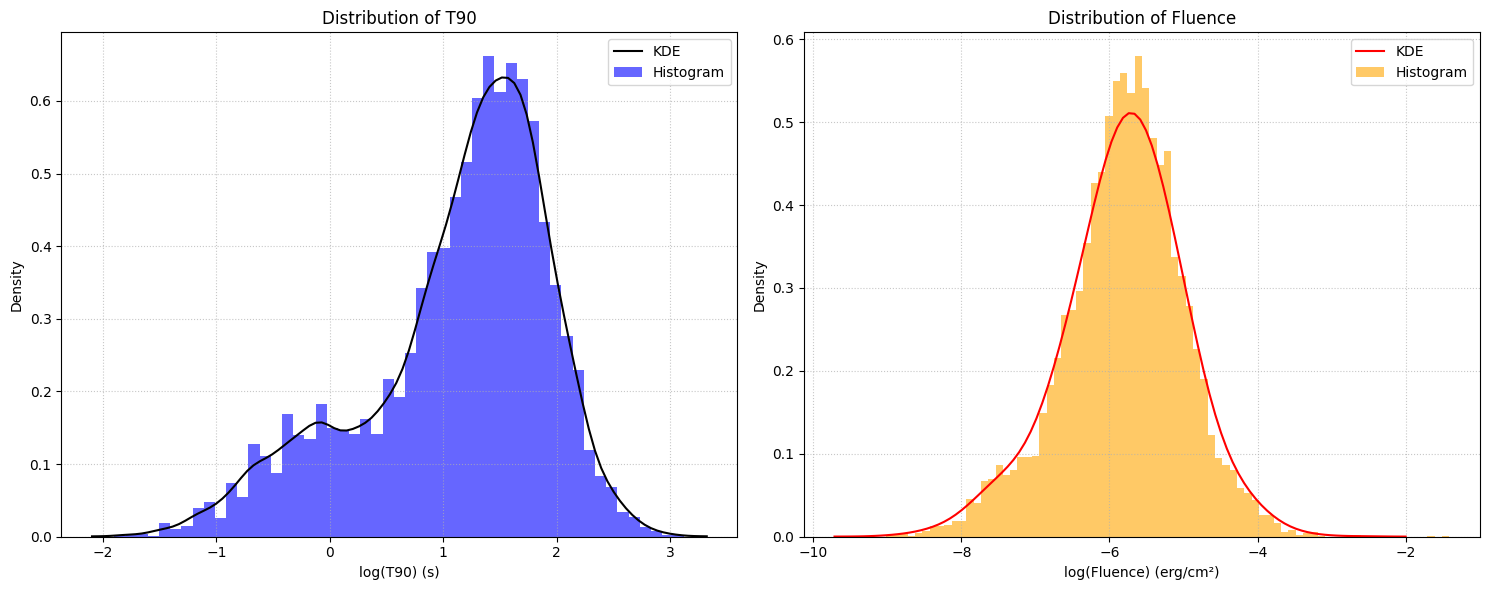

In [264]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# First histogram: T90
logT90 = np.log10(T90)
xgrid1 = np.linspace(logT90.min(), logT90.max(), 100)  # scala lineare nello spazio log
pdf1 = kde_sklearn(logT90, bandwidth=h_opt_arr[1], xgrid=xgrid1)
ax1.plot(xgrid1, pdf1, label='KDE', color='black')
ax1.hist(logT90, bins="fd", color='blue', density=True, alpha=0.6, label='Histogram')
ax1.set_title('Distribution of T90')
ax1.set_xlabel('log(T90) (s)')
ax1.set_ylabel('Density')
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend()

# Second histogram: fluence
logfluence = np.log10(fluence)
xgrid2 = np.linspace(logfluence.min(), -2, 100)
pdf2 = kde_sklearn(logfluence, bandwidth=h_opt_arr[0], xgrid=xgrid2)
ax2.plot(xgrid2, pdf2, label='KDE', color='red')
ax2.hist(logfluence, bins="fd", color='orange', density=True, alpha=0.6, label='Histogram')
ax2.set_title('Distribution of Fluence')
ax2.set_xlabel('log(Fluence) (erg/cm²)')
ax2.set_ylabel('Density')
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()


In [265]:
peaks_T90, _ = find_peaks(pdf1)

print(f"Number of peaks found for T90: {len(peaks_T90)}")
print(f"Peaks at values of T90 (log10): {xgrid1[peaks_T90]}")

peaks_fluence, _ = find_peaks(pdf2)

print(f"Number of peaks found for Fluence: {len(peaks_fluence)}")
print(f"Peaks at values of Fluence (log10): {xgrid2[peaks_fluence]}")

Number of peaks found for T90: 2
Peaks at values of T90 (log10): [-0.07157886  1.51584286]
Number of peaks found for Fluence: 1
Peaks at values of Fluence (log10): [-5.74015046]



I see from these plots that there seem to be one type of bursts in terms of the fluence, while there are perhaps two distinct populations of bursts in terms of the duration. I will try to inverstigate the latter hypothesis using the clustering methods we saw in our lecture.

### Clustering


From the KDE it seems that only $\log{T_{90}}$ has an evident bimodality, hence my choice to investigate only its shape. 
I will try to first set $n_{cl} = 2$, just to see if something sensed comes out.

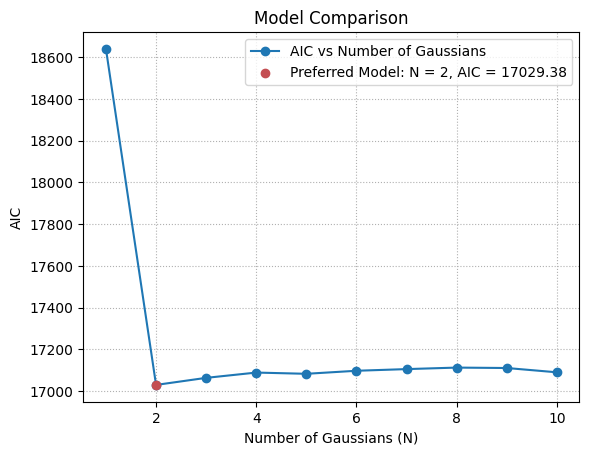

In [266]:
AIC = []
n_components = np.arange(1,11)

for i in n_components:
    model = GaussianMixture(i)
    model.fit(X_t)
    aic = model.aic(X_t)
    AIC.append(aic)

AIC = np.array(AIC)
n_best_index = np.argmin(AIC)
n_best = n_components[n_best_index]
best_aic = AIC[n_best_index] 

plt.plot(n_components, AIC,  marker='o', label = "AIC vs Number of Gaussians")
plt.scatter(n_best, best_aic, color='r', label=f"Preferred Model: N = {n_best}, AIC = {best_aic:.2f}", zorder=5)

plt.title("Model Comparison")
plt.xlabel("Number of Gaussians (N)")
plt.ylabel("AIC")
plt.legend()
plt.grid(linestyle = ":")
plt.show()


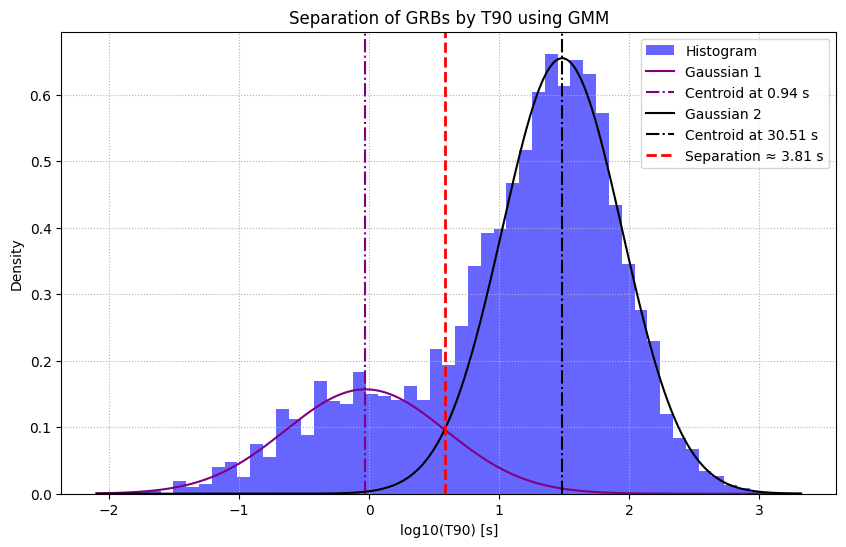

GMM means: [ 0.93728282 30.51165651]
Separation point: 3.809313750439435 s


In [267]:
n_clusters = 2
gmm = GaussianMixture(n_components=n_clusters, random_state=42)
gmm.fit(X_t)
labels = gmm.predict(X_t)

# Punti per disegnare le gaussiane
xgrid = np.linspace(logT90.min(), logT90.max(), 1000).reshape(-1,1)

# Calcolo delle singole gaussiane dal GMM
means = gmm.means_.flatten()
stds = np.sqrt(gmm.covariances_.flatten())
weights = gmm.weights_

plt.figure(figsize=(10,6))
colors = ["purple", "black"]

# Histogram
plt.hist(logT90, bins="fd", color='blue', density=True, alpha=0.6, edgecolor='none', label='Histogram')

# Gaussians
for i in range(n_clusters):
    mean = means[i]
    std = stds[i]
    weight = weights[i]
    
    gaussian = weight * (1/(std*np.sqrt(2*np.pi))) * np.exp(-0.5*((xgrid.flatten()-mean)/std)**2)
    plt.plot(xgrid, gaussian, color=colors[i], label=f'Gaussian {i+1}')
    plt.axvline(mean, color=colors[i], linestyle='-.', label=f'Centroid at {10**mean:.2f} s')

# Intersection point
from scipy.optimize import fsolve
def gaussian_pdf(x, mean, std, weight):
    return weight * (1/(std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean)/std)**2)
def diff(x):
    return gaussian_pdf(x, means[0], stds[0], weights[0]) - gaussian_pdf(x, means[1], stds[1], weights[1])
x_intersection = fsolve(diff, x0=(means[0] + means[1]) / 2)[0]
plt.axvline(x_intersection, color='red', linestyle='--', linewidth=2, label=f'Separation ≈ {10**x_intersection:.2f} s')

# Labels
plt.xlabel('log10(T90) [s]')
plt.ylabel('Density')
plt.title('Separation of GRBs by T90 using GMM')
plt.legend()
plt.grid(True, linestyle=":")
plt.show()

print("GMM means:", 10**means)
print("Separation point:", f'{10**x_intersection} s')

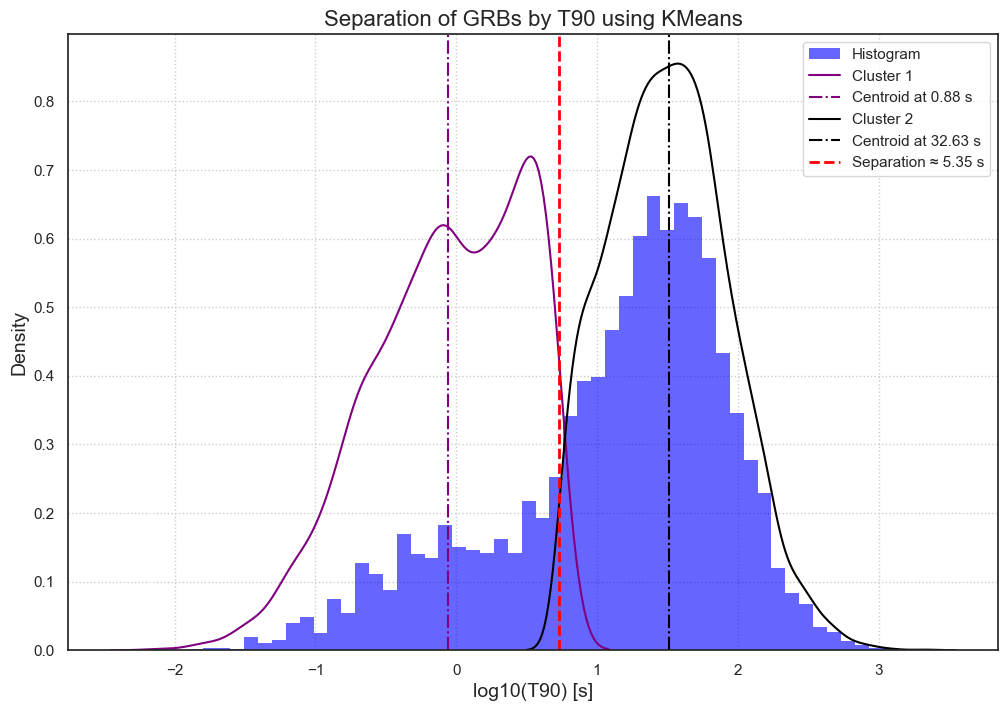

KMeans centroids: [ 0.8762506  32.63350715]
Separation point: 5.347441475028743 s


In [268]:
# Fit KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_t)
labels = kmeans.labels_
Y_t = kmeans.predict(X_t)

centroids = kmeans.cluster_centers_.flatten()

# Visualization setup
colors = ["purple", "black"]
sns.set(rc={'figure.figsize': (12, 8)})
sns.set_style("white")

# Histogram
plt.hist(logT90, bins="fd", color='blue', density=True, alpha=0.6, edgecolor='none', label='Histogram')

# KDEs and centroids
for i in range(n_clusters):
    centroid = centroids[i]
    sns.kdeplot(np.log10(T90[Y_t == i]), color=colors[i], label=f'Cluster {i+1}', common_norm=False)
    plt.axvline(centroid, linestyle='-.', color=colors[i], label=f'Centroid at {10**centroid:.2f} s')

# Separation line (midpoint between centroids)
separation_kmeans = np.mean(centroids)
plt.axvline(separation_kmeans, color='red', linestyle='--', linewidth=2, label=f'Separation ≈ {10**separation_kmeans:.2f} s')

# Final touches
plt.xlabel('log10(T90) [s]', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.title('Separation of GRBs by T90 using KMeans', fontsize=16)
plt.legend()
plt.grid(True, linestyle=":")
plt.show()

print("KMeans centroids:", 10**centroids)
print("Separation point:", f'{10**separation_kmeans} s')

From this initial analysis I learned two main things: 
    
- 1) The variable that shows the multi-modality more evidently is the $T_{90}$ one, while the other two seem to have just one mode;

- 2) The two clustering methods I used returned quite the same results, so they can be used indifferently for the 1-D analysis.

# 2-D distributions

In this section I am interested to test whether I could have studied the bimodality in the two-dimensional space. I decided to plot $\log{f}$ vs $\log{T_{90}}$, but I could have easily chosen also $z$ vs $\log{T_{90}}$ (just because this way I had a log-log plot).

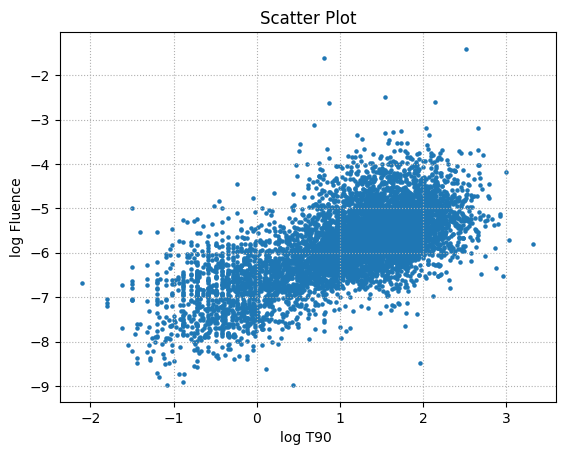

In [269]:
plt.style.use('default')

fig, ax = plt.subplots(1, 1)

mask = np.logical_and(T90_s>0, fluence_s>0)
fluence_corr = fluence_s[mask]
T90_corr = T90_s[mask]

plt.scatter(np.log10(T90_corr), np.log10(fluence_corr), s=5)
plt.xlabel('log T90 ')
plt.ylabel('log Fluence')
plt.title('Scatter Plot')
plt.grid(linestyle = ':')
plt.show()

In [270]:
matrix_val = np.array((np.log10(T90_corr), np.log10(fluence_corr)))
f_vs_t90 = matrix_val.transpose()

### KMeans

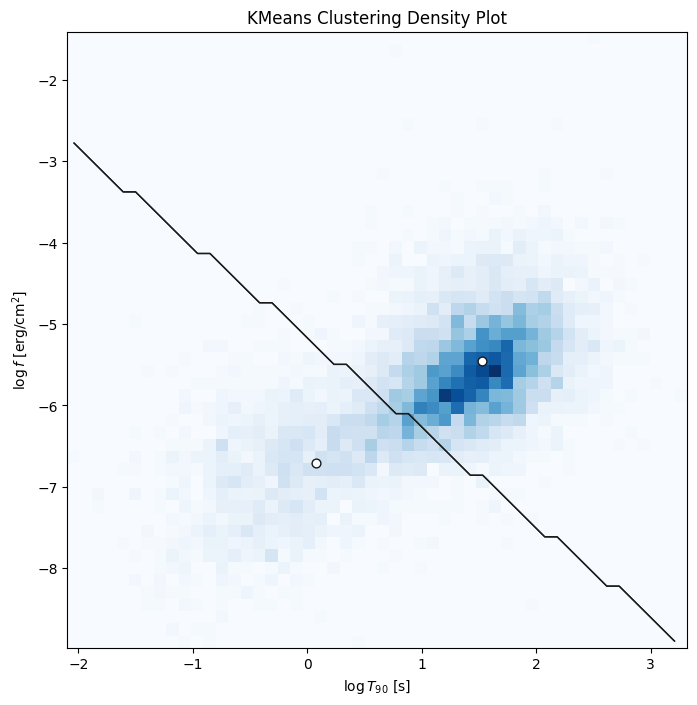

In [271]:
from sklearn.cluster import KMeans

# Prepare 2D feature space: log10(T90) and log10(Fluence)
X_2D = np.column_stack((np.log10(T90_corr), np.log10(fluence_corr)))

# KMeans clustering
n_clusters = 2
k_means = KMeans(n_clusters=n_clusters, random_state=42)
labels = k_means.fit_predict(X_2D)
cluster_centers = k_means.cluster_centers_

# Set up plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot()

# Compute 2D histogram (density)
H, xedges, yedges = np.histogram2d(X_2D[:, 0], X_2D[:, 1], bins=50)

# Plot density background
ax.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto',
          extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
          cmap='Blues')

# Plot cluster centers as white circles with black edges
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1], s=40, c='w', edgecolors='k')

# Compute grid centers for contour plotting
x_centers = 0.5 * (xedges[:-1] + xedges[1:])
y_centers = 0.5 * (yedges[:-1] + yedges[1:])

Xgrid = np.meshgrid(x_centers, y_centers)
Xgrid = np.array(Xgrid).reshape(2, 50*50).T

# Predict cluster labels for grid points
Z = k_means.predict(Xgrid).reshape(50, 50)

# Draw cluster boundaries as contour lines
for i in range(n_clusters):
    Hcp = (Z == i).astype(int)
    ax.contour(x_centers, y_centers, Hcp, levels=[0.5], colors='k', linewidths=1)

# Set axis limits and labels
ax.set_xlim(xedges[0], xedges[-1])
ax.set_ylim(yedges[0], yedges[-1])

ax.set_xlabel(r"$\log{T_{90}}$ [s]")
ax.set_ylabel(r"$\log{f}$ [erg/cm$^2$]")

ax.set_title("KMeans Clustering Density Plot")

plt.show()


In [272]:
# Extract centroids from log10 space
logT90_centroids = cluster_centers[:, 0]  # x-axis is log10(T90)

# Find the midpoint in log space
logT90_threshold = np.mean(logT90_centroids)

# Convert to linear T90
T90_threshold = 10**logT90_threshold

print(f"Estimated T90 separation threshold: {T90_threshold:.2f} s (log10: {logT90_threshold:.2f})")


Estimated T90 separation threshold: 6.34 s (log10: 0.80)


### MeanShift

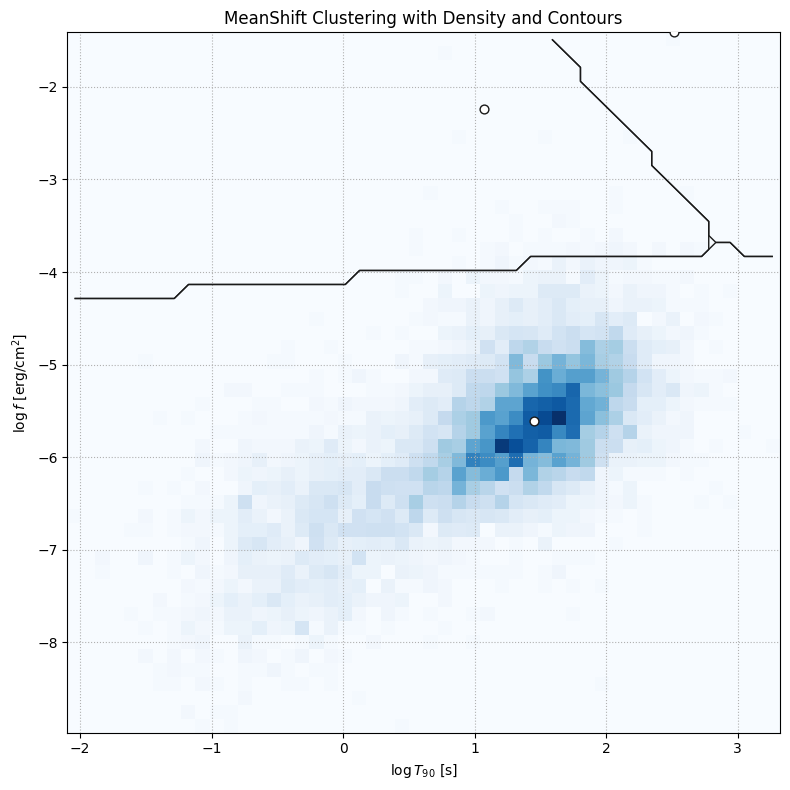

In [273]:
from sklearn.cluster import MeanShift, estimate_bandwidth

# Prepare feature space in log-log
X_2D = np.column_stack((np.log10(T90_corr), np.log10(fluence_corr)))

# Estimate bandwidth and fit MeanShift
bandwidth = estimate_bandwidth(X_2D)
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True, cluster_all=False)
labels = ms.fit_predict(X_2D)
centroids = ms.cluster_centers_

# Count points per cluster
labels_unique = np.unique(labels)
counts_tot = np.array([list(labels).count(u) for u in labels_unique])
n_clusters = np.sum(counts_tot > 1)

# Prepare plot
fig, ax = plt.subplots(figsize=(8, 8))

# 2D density histogram
H, xedges, yedges = np.histogram2d(X_2D[:, 0], X_2D[:, 1], bins=50)
ax.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto',
          extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
          cmap='Blues')

# Grid for contour prediction
x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])
Xgrid = np.meshgrid(x_centers, y_centers)
Xgrid_flat = np.array(Xgrid).reshape((2, -1)).T
H_pred = ms.predict(Xgrid_flat).reshape((50, 50))

# Plot contours for each cluster (if more than 1 point)
for i in range(len(centroids)):
    if counts_tot[i] > 1:
        mask = (H_pred == i).astype(int)
        ax.contour(x_centers, y_centers, mask, levels=[0.5],
                   linewidths=1, colors='k')

# Plot centroids
for i, (x, y) in enumerate(centroids):
    color = 'white' if counts_tot[i] > 1 else 'red'
    ax.scatter(x, y, s=40, c=color, edgecolors='k', zorder=5)

# Axis styling
ax.set_xlim(xedges[0], xedges[-1])
ax.set_ylim(yedges[0], yedges[-1])
ax.set_xlabel(r"$\log{T_{90}}$ [s]")
ax.set_ylabel(r"$\log{f}$ [erg/cm$^2$]")
ax.set_title("MeanShift Clustering with Density and Contours")
ax.grid(linestyle=':')

plt.tight_layout()
plt.show()


Here, we see how the behaviour is different. Apparently, the algorithm sees only one center in the bulge, and associates it with one of the three identified clusters' centres. I will try to change the bandwidth to see if anything improves.

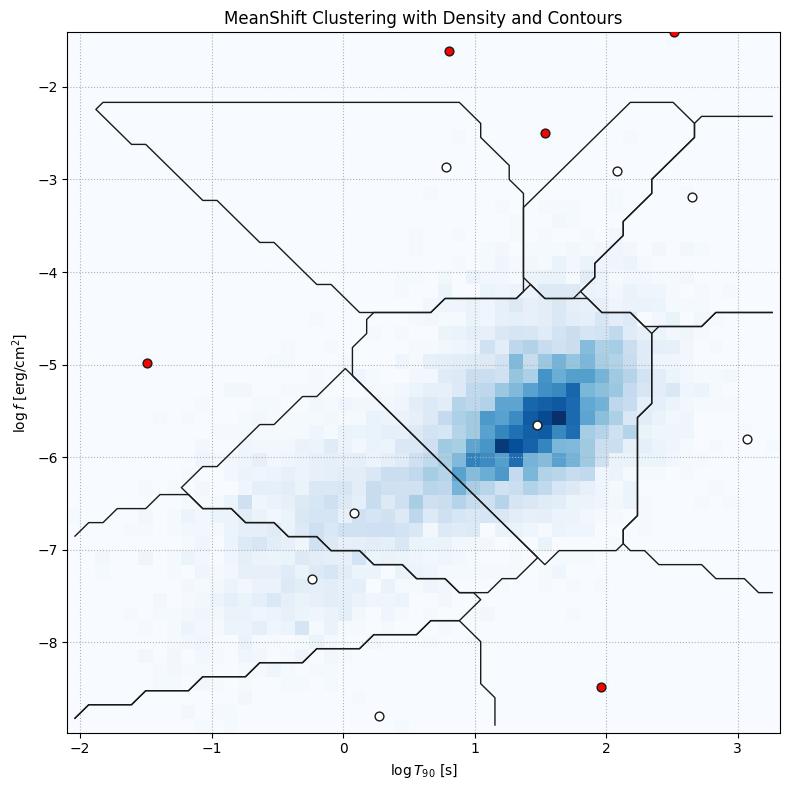

In [274]:
# Estimate bandwidth and fit MeanShift
ms = MeanShift(bandwidth=0.4, bin_seeding=True, cluster_all=False)
labels = ms.fit_predict(X_2D)
centroids = ms.cluster_centers_

# Count points per cluster
labels_unique = np.unique(labels)
counts_tot = np.array([list(labels).count(u) for u in labels_unique])
n_clusters = np.sum(counts_tot > 1)

# Prepare plot
fig, ax = plt.subplots(figsize=(8, 8))

# 2D density histogram
H, xedges, yedges = np.histogram2d(X_2D[:, 0], X_2D[:, 1], bins=50)
ax.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto',
          extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
          cmap='Blues')

# Grid for contour prediction
x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])
Xgrid = np.meshgrid(x_centers, y_centers)
Xgrid_flat = np.array(Xgrid).reshape((2, -1)).T
H_pred = ms.predict(Xgrid_flat).reshape((50, 50))

# Plot contours for each cluster (if more than 1 point)
for i in range(len(centroids)):
    if counts_tot[i] > 1:
        mask = (H_pred == i).astype(int)
        ax.contour(x_centers, y_centers, mask, levels=[0.5],
                   linewidths=1, colors='k')

# Plot centroids
for i, (x, y) in enumerate(centroids):
    color = 'white' if counts_tot[i] > 1 else 'red'
    ax.scatter(x, y, s=40, c=color, edgecolors='k', zorder=5)

# Axis styling
ax.set_xlim(xedges[0], xedges[-1])
ax.set_ylim(yedges[0], yedges[-1])
ax.set_xlabel(r"$\log{T_{90}}$ [s]")
ax.set_ylabel(r"$\log{f}$ [erg/cm$^2$]")
ax.set_title("MeanShift Clustering with Density and Contours")
ax.grid(linestyle=':')

plt.tight_layout()
plt.show()

The red centroids are the $\textbf{singletons}$. I hoped to see that mostly the algorithm was able to find two "real" centroids and the others were just resulting from the outliers effect on the gradient. I instead proved that the algorithm fails in this case to find a suitable number of clusters.

### Gaussian Mixture

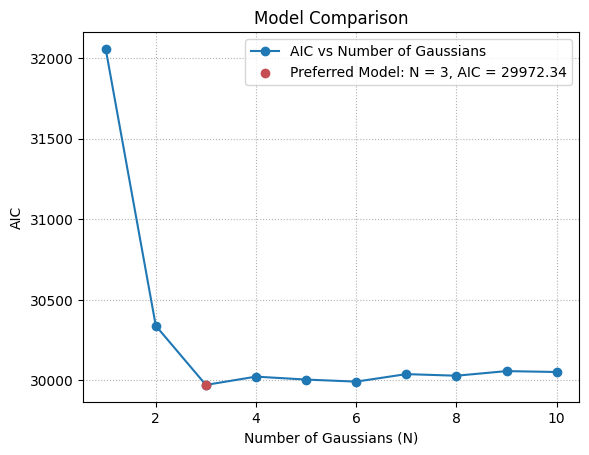

In [275]:
AIC = []
n_components = np.arange(1,11)

for i in n_components:
    model = GaussianMixture(i)
    model.fit(f_vs_t90)
    aic = model.aic(f_vs_t90)
    AIC.append(aic)

AIC = np.array(AIC)
n_best_index = np.argmin(AIC)
n_best = n_components[n_best_index]
best_aic = AIC[n_best_index] 

plt.plot(n_components, AIC,  marker='o', label = "AIC vs Number of Gaussians")
plt.scatter(n_best, best_aic, color='r', label=f"Preferred Model: N = {n_best}, AIC = {best_aic:.2f}", zorder=5)

plt.title("Model Comparison")
plt.xlabel("Number of Gaussians (N)")
plt.ylabel("AIC")
plt.legend()
plt.grid(linestyle = ":")
plt.show()

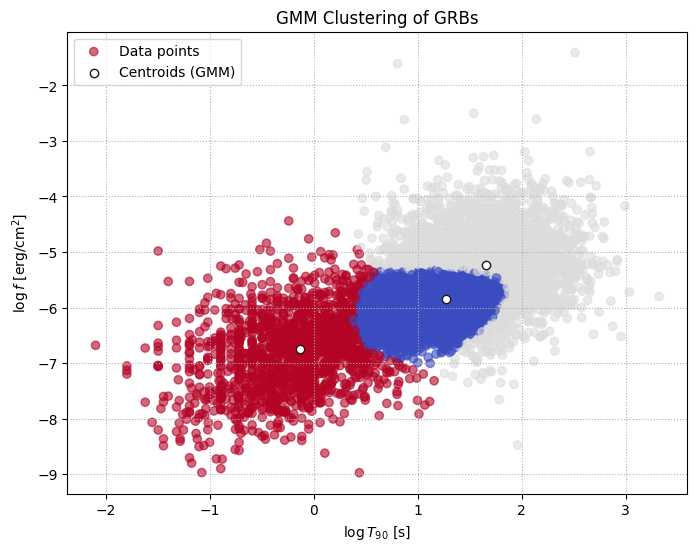

In [276]:
gmm = GaussianMixture(n_components=n_best, random_state=42)
gmm.fit(f_vs_t90)
c_gmm = gmm.predict(f_vs_t90)
centroids_gmm = gmm.means_

plt.figure(figsize=(8, 6))
plt.scatter(np.log10(T90_corr), np.log10(fluence_corr), c=c_gmm, cmap='coolwarm', alpha=0.6, label='Data points')
plt.scatter(centroids_gmm[:, 0], centroids_gmm[:, 1],
            c='white', marker='o', edgecolors='k', label='Centroids (GMM)')
plt.xlabel(r"$\log{T_{90}}$ [s]")
plt.ylabel(r"$\log{f}$ [erg/cm$^2$]")
plt.title('GMM Clustering of GRBs')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()


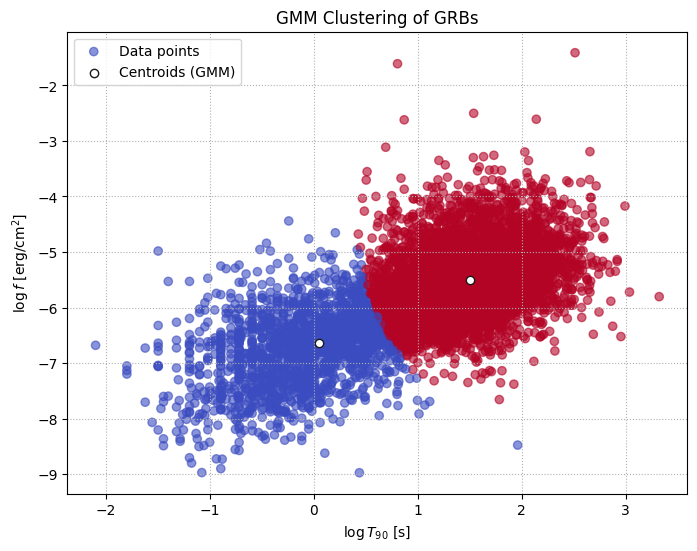

In [277]:
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(f_vs_t90)
c_gmm = gmm.predict(f_vs_t90)
centroids_gmm = gmm.means_

plt.figure(figsize=(8, 6))
plt.scatter(np.log10(T90_corr), np.log10(fluence_corr), c=c_gmm, cmap='coolwarm', alpha=0.6, label='Data points')
plt.scatter(centroids_gmm[:, 0], centroids_gmm[:, 1],
            c='white', marker='o', edgecolors='k', label='Centroids (GMM)')
plt.xlabel(r"$\log{T_{90}}$ [s]")
plt.ylabel(r"$\log{f}$ [erg/cm$^2$]")
plt.title('GMM Clustering of GRBs')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

In [278]:
from scipy.stats import norm

# Extract parameters of the Gaussians in log10(T90) space
means = gmm.means_[:, 0]              # log10(T90) means
stds = np.sqrt(gmm.covariances_[:, 0, 0])  # std devs for log10(T90)
weights = gmm.weights_                # mixing weights

# Sort components for consistent interpretation
order = np.argsort(means)
mu1, mu2 = means[order]
sigma1, sigma2 = stds[order]
w1, w2 = weights[order]

def mixture_diff(x):
    p1 = w1 * norm.pdf(x, mu1, sigma1)
    p2 = w2 * norm.pdf(x, mu2, sigma2)
    return p1 - p2

# Initial guess near the midpoint
x0 = (mu1 + mu2) / 2

# Solve using fsolve
boundary_log_t90 = fsolve(mixture_diff, x0)[0]
boundary_t90 = 10 ** boundary_log_t90

print(f"Decision boundary (log10 T90): {boundary_log_t90:.3f}")
print(f"Decision boundary (T90): {boundary_t90:.2f} seconds")

Decision boundary (log10 T90): 0.634
Decision boundary (T90): 4.31 seconds


#### **Physics Perspective**

The analysis suggests the presence of two somewhat distinct groups of gamma-ray bursts, distinguished primarily by their duration. Other features appear to follow a more unimodal distribution. Literature supports this observation: gamma-ray bursts are typically classified into two categories based on duration:

- **Long GRBs**, with an average duration around 30 seconds  
- **Short GRBs**, averaging roughly 0.3 seconds  

A commonly accepted boundary between the two is approximately **2 seconds**.

---

#### **Algorithmic Perspective**

Among the clustering methods I tried, **MeanShift** turned out to be the most sensitive to outliers. It often detected too many clusters, likely because it uses a method that looks at the density of nearby points. When some points are far away from the others, they can still affect this density calculation and cause the algorithm to find extra, unnecessary clusters.


# What about the errors?

I did not mention anything concerning the errors in data, that were still present in the dataset: I am now going to check whether that affects my analysis significantly or not.

In [279]:
T90_s_err = np.array(data[7],dtype=float)
fluence_s_err = np.array(data[10],dtype=float)

In [280]:
mask = np.logical_and(T90_s>0, fluence_s>0)

fluence_err_corr = fluence_s_err[mask]
T90_err_corr = T90_s_err[mask]

T90_corr = T90_s[mask]
fluence_corr = fluence_s[mask]

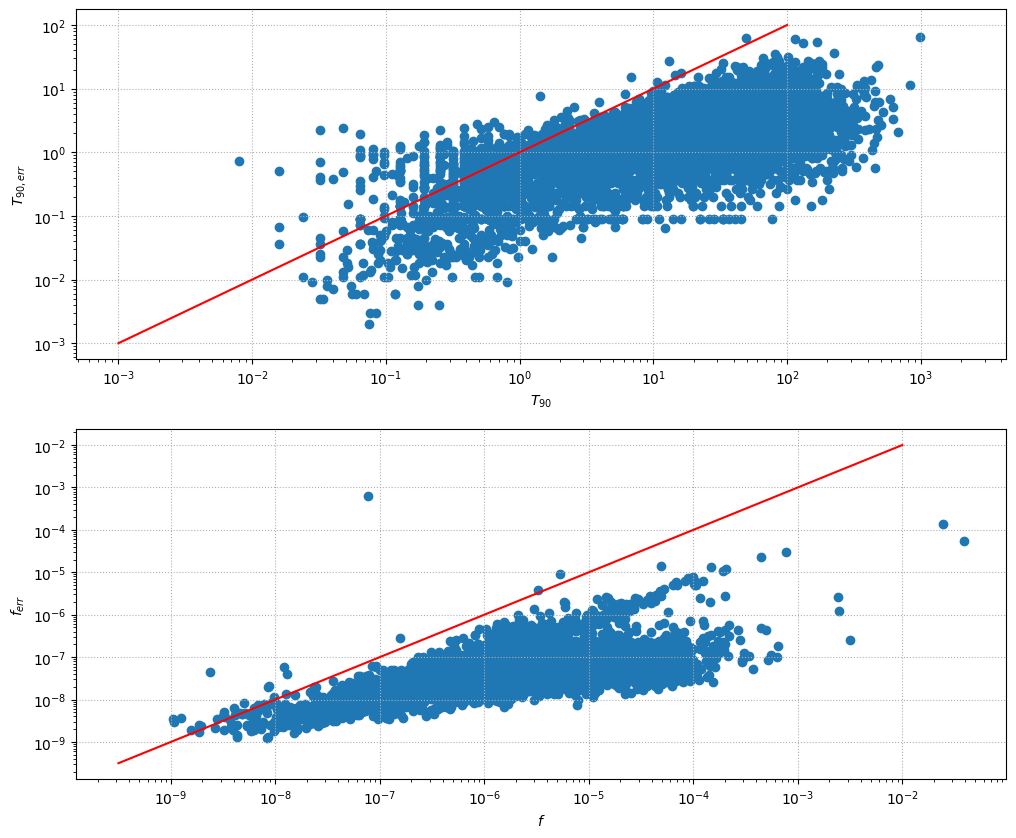

In [281]:
xgrid_t = np.logspace(-3, 2, 4) 
xgrid_f = np.logspace(-9.5, -2, 4)

fig, ax = plt.subplots(2, figsize=(12, 10))

ax[0].scatter(T90_corr, T90_err_corr)
ax[0].plot(xgrid_t, xgrid_t, '-', c='red')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel('$T_{90}$')
ax[0].set_ylabel('$T_{90, err}$')
ax[0].grid(linestyle = ':')

ax[1].scatter(fluence_corr, fluence_err_corr)  # in both cases check if the error is of the order of the measurement
ax[1].plot(xgrid_f, xgrid_f, '-', c='red')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlabel('$f$')
ax[1].set_ylabel('$f_{err}$'); 
ax[1].grid(linestyle = ':')

This should be telling me that it's okay not to use the error in my analysis, since it's $\textit{relatively}$ very small for all quantities. 